<a href="https://colab.research.google.com/github/Joaoplims/NLP_Gametox/blob/main/NLP_Gametox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TODO


## 📋 Checklist de Execução do Experimento

### 🛠️ 1. Preparação dos Dados Reais (GameTox)

* [ ] **Carga e Filtragem:** Carregar o dataset do GameTox e filtrar as 42.963 mensagens pertencentes ao subconjunto em inglês.


* [ ] **Inspeção das Classes:** Mapear a contagem exata das 6 classes de *Intent* (*Non-Toxic*, *Insults and Flaming*, *Other Offensive Texts*, *Hate and Harassment*, *Threats*, *Extremism*) para documentar a linha de base do desbalanceamento.


* [ ] **Pré-processamento e Normalização:**
* [ ] Converter todo o texto para caixa baixa (*lowercase*).


* [ ] Tratar/remover caracteres especiais, pontuações desnecessárias.


* [ ] Criar uma rotina de tokenização adequada preservando pontuações e expressões típicas do contexto *gamer* (ex: *n00b*, *kys*, *fck*).


* [ ] **Garantia de Integridade:** Isolar o conjunto de **Teste Real** (nenhum dado sintético deve entrar aqui sob hipótese alguma).





---

### ⚙️ 2. Construção da Baseline (Sem Dados Sintéticos)

* [ ] **Vetorização dos Dados de Treino:**
* [ ] Extrair representações **TF-IDF** (testando uni-grams e bi-grams).
* [ ] Extrair/gerar representações densas via **Word2Vec** (treinado no próprio corpus de treino ou usando um modelo pré-treinado adaptado).


* [ ] **Treinamento de Modelos Clássicos:**
* [ ] Treinar os modelos selecionados (ex: *Regressão Logística*, *SVM*, *Naive Bayes*, *Random Forest*) apenas com o **Treino Real Desbalanceado**.




* [ ] **Avaliação e Métricas de Referência:**
* [ ] Avaliar a baseline no conjunto de **Teste Real**.


* [ ] Registrar o **Macro F1-Score**, o **F1-Score individual por classe** e a **Matriz de Confusão** (espera-se desempenho muito baixo ou nulo nas classes raras: *Threats*, *Extremism*, *Hate*).





---

### 🤖 3. Geração e Validação de Dados Sintéticos (LLM)

* [ ] **Engenharia de Prompt:**
* [ ] Escrever prompts estruturados (*Single-Agent* ou *Multi-Agent*) fornecendo exemplos reais (*few-shot*) das classes minoritárias (*Threats*, *Extremism*, *Hate and Harassment*).


* [ ] Instruir a LLM a simular a linguagem informal, ruidosa e cheia de gírias do ambiente de jogos digitais.




* [ ] **Geração e Filtragem:**
* [ ] Gerar amostras sintéticas suficientes para equilibrar proporcionalmente as classes raras em relação às classes majoritárias no conjunto de treino.


* [ ] Fazer uma checagem de qualidade/limpeza no texto gerado (remover saídas polidas demais ou respostas que fujam do formato do chat).




* [ ] **Consolidação das Bases de Treino:**
* [ ] **Treino A (Baseline):** 100% Real.


* [ ] **Treino B (Tradicional):** Real + SMOTE / Random Oversampling nos vetores.
* [ ] **Treino C (Proposta LLM):** Real + Dados Sintéticos gerados.





---

### 🧪 4. Experimentos Comparativos e Treinamento

* [ ] **Re-vetorizar** os novos conjuntos de treino estendidos (B e C) utilizando exatamente os mesmos parâmetros de TF-IDF e Word2Vec definidos no Passo 2.
* [ ] **Treinar os classificadores** em cada um dos cenários de treino (A, B e C) mantendo os mesmos hiperparâmetros.

---

### 📊 5. Avaliação Final, Análise e Discussão

* [ ] **Avaliação Padronizada:** Avaliar todos os modelos resultantes exatamente sobre o mesmo conjunto de **Teste Real** (mantido intacto).


* [ ] **Métricas e Tabelas:**
* [ ] Gerar a tabela comparativa contendo: **Precision**, **Recall**, **Macro F1-Score** e **F1-Score por classe** para cada modelo/cenário.


* [ ] Plotar as **Matrizes de Confusão** comparativas (Baseline vs. SMOTE vs. Sintético LLM).




* [ ] **Análise de Erros (Qualitativa):**
* [ ] Analisar falsos positivos e falsos negativos: O dado sintético ajudou o modelo a generalizar sem causar overfit ao estilo do LLM?


* [ ] Verificar se gírias neutras de jogos foram confundidas com frases tóxicas sintéticas.


# Dependencias:

In [8]:
pip install gensim

In [9]:
!pip install google-genai pandas -q

# Datasets


In [10]:
val = "https://raw.githubusercontent.com/Joaoplims/NLP_Gametox/refs/heads/main/val-gametox/val/val.csv"
train = "https://raw.githubusercontent.com/Joaoplims/NLP_Gametox/refs/heads/main/train-gametox/train/train.csv"
test_label = "https://raw.githubusercontent.com/Joaoplims/NLP_Gametox/refs/heads/main/test_release-gametox/test_release/test_index_label.csv"
test_msg = "https://raw.githubusercontent.com/Joaoplims/NLP_Gametox/refs/heads/main/test_release-gametox/test_release/test_index_text.csv"

In [11]:
import pandas as pd
import re

# 1. Carregar os CSVs originais
df_train = pd.read_csv(train)
df_val = pd.read_csv(val)
df_test_msgs = pd.read_csv(test_msg)
df_test_lbls = pd.read_csv(test_label)
df_test = pd.merge(df_test_msgs, df_test_lbls, on='index')

# Função para checar se a mensagem NÃO contém caracteres cirílicos
def is_clean_english(text):
    return not bool(re.search(r'[\u0400-\u04FF]', str(text)))

# 2. Filtrar cada split
train_clean = df_train[df_train['message'].apply(is_clean_english)].copy()
val_clean   = df_val[df_val['message'].apply(is_clean_english)].copy()
test_clean  = df_test[df_test['message'].apply(is_clean_english)].copy()

# 3. Salvar os datasets filtrados
train_clean.to_csv('train_clean.csv', index=False)
val_clean.to_csv('val_clean.csv', index=False)
test_clean.to_csv('test_clean.csv', index=False)

print("=== SPLITS LIMPOS TEXTOS EM INGLÊS ===")
print(f"Treino:     {len(train_clean)} amostras")
print(f"Validação:  {len(val_clean)} amostras")
print(f"Teste Real: {len(test_clean)} amostras")
print(f"Total:      {len(train_clean) + len(val_clean) + len(test_clean)} amostras")

=== SPLITS LIMPOS TEXTOS EM INGLÊS ===
Treino:     39995 amostras
Validação:  4986 amostras
Teste Real: 4986 amostras
Total:      49967 amostras


In [12]:
import pandas as pd

# Mapeamento das classes conforme a documentação do GameTox
class_mapping = {
    0.0: "Non-Toxic",
    1.0: "Insults and Flaming",
    2.0: "Other Offensive Texts",
    3.0: "Hate and Harassment",
    4.0: "Threats",
    5.0: "Extremism"
}

# Contagem no conjunto de treino limpo
class_counts = train_clean['label'].value_counts().sort_index().rename(index=class_mapping)
class_percentages = (train_clean['label'].value_counts(normalize=True) * 100).sort_index().rename(index=class_mapping)

# Criando um DataFrame para visualização
imbalance_report = pd.DataFrame({
    'Amostras': class_counts,
    'Porcentagem (%)': class_percentages.map('{:.2f}%'.format)
})

print("=== DISTRIBUIÇÃO DAS CLASSES (TRAIN_CLEAN) ===")
print(imbalance_report)

=== DISTRIBUIÇÃO DAS CLASSES (TRAIN_CLEAN) ===
                       Amostras Porcentagem (%)
label                                          
Non-Toxic                 32511          81.29%
Insults and Flaming        5435          13.59%
Other Offensive Texts      1755           4.39%
Hate and Harassment         216           0.54%
Threats                      55           0.14%
Extremism                    23           0.06%


# Pre processamento do Dataset

In [13]:
import re

def preprocess_gamer_text(text):
    if not isinstance(text, str):
        return ""
    # Converter para caixa baixa
    text = text.lower()
    # Remover caracteres especiais, mas manter o que é comum em chats (letras, números e espaços)
    # Mantemos alguns símbolos que podem ser usados em gírias ou censura (como *)
    text = re.sub(r'[^a-z0-9\s\*]', '', text)
    # Remover espaços extras
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Aplicando a limpeza nos DataFrames limpos
train_clean['message_preprocessed'] = train_clean['message'].apply(preprocess_gamer_text)
val_clean['message_preprocessed'] = val_clean['message'].apply(preprocess_gamer_text)
test_clean['message_preprocessed'] = test_clean['message'].apply(preprocess_gamer_text)

print("=== PRÉ-PROCESSAMENTO CONCLUÍDO ===")
print("Exemplos de antes e depois (Treino):")
display(train_clean[['message', 'message_preprocessed']].head(10))

=== PRÉ-PROCESSAMENTO CONCLUÍDO ===
Exemplos de antes e depois (Treino):


,message,message_preprocessed
0,no rush,no rush
1,whatever ... watch the replay,whatever watch the replay
2,useless,useless
3,3 gunmark,3 gunmark
4,lol,lol
5,i softened him lol,i softened him lol
6,come,come
7,stupid kids grow up,stupid kids grow up
8,fking light diference,fking light diference
9,"hori, info ?",hori info


# Vetorização

## TF-IDF

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inicializar o TF-IDF Vectorizer
# Usaremos unigramas e bigramas (ngram_range=(1, 2)) e limitaremos a 10.000 features para eficiência
tfidf_vect = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)

# 1. Ajustar e transformar o conjunto de TREINO
X_train_tfidf = tfidf_vect.fit_transform(train_clean['message_preprocessed'])

# 2. Apenas transformar os conjuntos de VALIDAÇÃO e TESTE
X_val_tfidf = tfidf_vect.transform(val_clean['message_preprocessed'])
X_test_tfidf = tfidf_vect.transform(test_clean['message_preprocessed'])

# Rótulos (y)
y_train = train_clean['label']
y_val = val_clean['label']
y_test = test_clean['label']

print("=== VETORIZAÇÃO TF-IDF CONCLUÍDA ===")
print(f"Shape Treino:     {X_train_tfidf.shape}")
print(f"Shape Validação:  {X_val_tfidf.shape}")
print(f"Shape Teste Real: {X_test_tfidf.shape}")

=== VETORIZAÇÃO TF-IDF CONCLUÍDA ===
Shape Treino:     (39995, 10000)
Shape Validação:  (4986, 10000)
Shape Teste Real: (4986, 10000)


## Word2Vec

In [15]:
from gensim.models import Word2Vec
import numpy as np

# 1. Preparar os tokens para o Word2Vec (apenas treino)
train_sentences = [text.split() for text in train_clean['message_preprocessed']]

# 2. Treinar o modelo Word2Vec
# vector_size=100, window=5, min_count=2 para cobrir gírias recorrentes
w2v_model = Word2Vec(sentences=train_sentences, vector_size=100, window=5, min_count=2, workers=4, seed=42)

# 3. Função para transformar mensagem em vetor médio (Sentença -> Vetor)
def get_average_word2vec(tokens, model, vector_size):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not valid_vectors:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

# 4. Vetorizar os datasets (Treino, Validação e Teste)
X_train_w2v = np.array([get_average_word2vec(text.split(), w2v_model, 100) for text in train_clean['message_preprocessed']])
X_val_w2v = np.array([get_average_word2vec(text.split(), w2v_model, 100) for text in val_clean['message_preprocessed']])
X_test_w2v = np.array([get_average_word2vec(text.split(), w2v_model, 100) for text in test_clean['message_preprocessed']])

print("=== VETORIZAÇÃO WORD2VEC CONCLUÍDA ===")
print(f"Shape Treino W2V: {X_train_w2v.shape}")
print(f"Shape Teste W2V:  {X_test_w2v.shape}")

=== VETORIZAÇÃO WORD2VEC CONCLUÍDA ===
Shape Treino W2V: (39995, 100)
Shape Teste W2V:  (4986, 100)


In [16]:
from gensim.models import Word2Vec
import numpy as np

# 1. Preparar os tokens para o Word2Vec
train_sentences = [text.split() for text in train_clean['message_preprocessed']]

# 2. Treinar o modelo Word2Vec
# vector_size=100 (dimensões), window=5, min_count=2 para ignorar palavras muito raras
w2v_model = Word2Vec(sentences=train_sentences, vector_size=100, window=5, min_count=2, workers=4, seed=42)

# 3. Função para transformar mensagem em vetor médio
def get_average_word2vec(tokens, model, vector_size):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not valid_vectors:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

# 4. Vetorizar os datasets
X_train_w2v = np.array([get_average_word2vec(text.split(), w2v_model, 100) for text in train_clean['message_preprocessed']])
X_val_w2v = np.array([get_average_word2vec(text.split(), w2v_model, 100) for text in val_clean['message_preprocessed']])
X_test_w2v = np.array([get_average_word2vec(text.split(), w2v_model, 100) for text in test_clean['message_preprocessed']])

print("=== VETORIZAÇÃO WORD2VEC CONCLUÍDA ===")
print(f"Shape Treino W2V: {X_train_w2v.shape}")
print(f"Exemplo de vetor (primeiros 5 elementos): {X_train_w2v[0][:5]}")

=== VETORIZAÇÃO WORD2VEC CONCLUÍDA ===
Shape Treino W2V: (39995, 100)
Exemplo de vetor (primeiros 5 elementos): [ 0.13149582 -0.1077962  -0.04619826  0.18880659 -0.37285998]


# Modelos de Classificação

## TF-IDF

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. Regressão Logística
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_lr.fit(X_train_tfidf, y_train)

# Predição e Avaliação
y_pred_lr = model_lr.predict(X_test_tfidf)

print("=== BASELINE: REGRESSÃO LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr, target_names=list(class_mapping.values())))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

=== BASELINE: REGRESSÃO LOGÍSTICA ===
                       precision    recall  f1-score   support

            Non-Toxic       0.95      0.85      0.90      4044
  Insults and Flaming       0.67      0.68      0.68       681
Other Offensive Texts       0.25      0.61      0.36       222
  Hate and Harassment       0.11      0.38      0.17        29
              Threats       0.08      0.38      0.13         8
            Extremism       0.25      0.50      0.33         2

             accuracy                           0.82      4986
            macro avg       0.39      0.57      0.43      4986
         weighted avg       0.88      0.82      0.84      4986

Macro F1-Score: 0.4277


In [18]:
from sklearn.svm import LinearSVC

# 2. SVM (Linear)
model_svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
model_svm.fit(X_train_tfidf, y_train)

# Predição e Avaliação
y_pred_svm = model_svm.predict(X_test_tfidf)

print("=== BASELINE: SVM (LINEAR) ===")
print(classification_report(y_test, y_pred_svm, target_names=list(class_mapping.values())))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_svm, average='macro'):.4f}")

=== BASELINE: SVM (LINEAR) ===
                       precision    recall  f1-score   support

            Non-Toxic       0.94      0.93      0.94      4044
  Insults and Flaming       0.74      0.67      0.70       681
Other Offensive Texts       0.36      0.48      0.41       222
  Hate and Harassment       0.23      0.38      0.29        29
              Threats       0.20      0.25      0.22         8
            Extremism       0.00      0.00      0.00         2

             accuracy                           0.87      4986
            macro avg       0.41      0.45      0.43      4986
         weighted avg       0.88      0.87      0.87      4986

Macro F1-Score: 0.4265


In [19]:
from sklearn.naive_bayes import MultinomialNB

# 3. Naive Bayes (Multinomial)
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

# Predição e Avaliação
y_pred_nb = model_nb.predict(X_test_tfidf)

print("=== BASELINE: NAIVE BAYES ===")
print(classification_report(y_test, y_pred_nb, target_names=list(class_mapping.values())))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_nb, average='macro'):.4f}")

=== BASELINE: NAIVE BAYES ===
                       precision    recall  f1-score   support

            Non-Toxic       0.88      0.99      0.93      4044
  Insults and Flaming       0.83      0.52      0.64       681
Other Offensive Texts       0.84      0.07      0.13       222
  Hate and Harassment       0.00      0.00      0.00        29
              Threats       0.00      0.00      0.00         8
            Extremism       0.00      0.00      0.00         2

             accuracy                           0.88      4986
            macro avg       0.43      0.26      0.28      4986
         weighted avg       0.87      0.88      0.85      4986

Macro F1-Score: 0.2849


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
from sklearn.ensemble import RandomForestClassifier

# 4. Random Forest
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf.fit(X_train_tfidf, y_train)

# Predição e Avaliação
y_pred_rf = model_rf.predict(X_test_tfidf)

print("=== BASELINE: RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=list(class_mapping.values())))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")

=== BASELINE: RANDOM FOREST ===
                       precision    recall  f1-score   support

            Non-Toxic       0.92      0.86      0.89      4044
  Insults and Flaming       0.76      0.62      0.68       681
Other Offensive Texts       0.48      0.36      0.41       222
  Hate and Harassment       0.26      0.31      0.28        29
              Threats       0.05      0.12      0.07         8
            Extremism       0.00      0.00      0.00         2

             accuracy                           0.80      4986
            macro avg       0.41      0.38      0.39      4986
         weighted avg       0.87      0.80      0.83      4986

Macro F1-Score: 0.3892


## Word2Vec

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# 1. Regressão Logística (Word2Vec)
model_lr_w2v = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_lr_w2v.fit(X_train_w2v, y_train)

y_pred_lr_w2v = model_lr_w2v.predict(X_test_w2v)

print("=== BASELINE W2V: REGRESSÃO LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr_w2v, target_names=list(class_mapping.values())))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_lr_w2v, average='macro'):.4f}")

=== BASELINE W2V: REGRESSÃO LOGÍSTICA ===
                       precision    recall  f1-score   support

            Non-Toxic       0.94      0.43      0.59      4044
  Insults and Flaming       0.53      0.46      0.49       681
Other Offensive Texts       0.14      0.46      0.21       222
  Hate and Harassment       0.02      0.34      0.04        29
              Threats       0.01      0.50      0.01         8
            Extremism       0.00      0.00      0.00         2

             accuracy                           0.43      4986
            macro avg       0.27      0.37      0.22      4986
         weighted avg       0.84      0.43      0.55      4986

Macro F1-Score: 0.2241


In [22]:
from sklearn.svm import LinearSVC

# 2. SVM (Word2Vec)
model_svm_w2v = LinearSVC(class_weight='balanced', random_state=42, max_iter=5000)
model_svm_w2v.fit(X_train_w2v, y_train)

y_pred_svm_w2v = model_svm_w2v.predict(X_test_w2v)

print("=== BASELINE W2V: SVM (LINEAR) ===")
print(classification_report(y_test, y_pred_svm_w2v, target_names=list(class_mapping.values())))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_svm_w2v, average='macro'):.4f}")

=== BASELINE W2V: SVM (LINEAR) ===
                       precision    recall  f1-score   support

            Non-Toxic       0.88      0.92      0.90      4044
  Insults and Flaming       0.65      0.42      0.51       681
Other Offensive Texts       0.35      0.23      0.28       222
  Hate and Harassment       0.00      0.00      0.00        29
              Threats       0.06      0.12      0.08         8
            Extremism       0.00      0.00      0.00         2

             accuracy                           0.82      4986
            macro avg       0.32      0.28      0.29      4986
         weighted avg       0.82      0.82      0.81      4986

Macro F1-Score: 0.2941


In [23]:
from sklearn.naive_bayes import GaussianNB

# 3. Naive Bayes (Gaussian para vetores densos)
model_nb_w2v = GaussianNB()
model_nb_w2v.fit(X_train_w2v, y_train)

y_pred_nb_w2v = model_nb_w2v.predict(X_test_w2v)

print("=== BASELINE W2V: NAIVE BAYES (GAUSSIAN) ===")
print(classification_report(y_test, y_pred_nb_w2v, target_names=list(class_mapping.values())))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_nb_w2v, average='macro'):.4f}")

=== BASELINE W2V: NAIVE BAYES (GAUSSIAN) ===
                       precision    recall  f1-score   support

            Non-Toxic       0.92      0.10      0.18      4044
  Insults and Flaming       0.18      0.40      0.25       681
Other Offensive Texts       0.05      0.06      0.06       222
  Hate and Harassment       0.03      0.45      0.05        29
              Threats       0.00      0.25      0.00         8
            Extremism       0.00      0.00      0.00         2

             accuracy                           0.14      4986
            macro avg       0.20      0.21      0.09      4986
         weighted avg       0.78      0.14      0.18      4986

Macro F1-Score: 0.0899


In [24]:
from sklearn.ensemble import RandomForestClassifier

# 4. Random Forest (Word2Vec)
model_rf_w2v = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf_w2v.fit(X_train_w2v, y_train)

y_pred_rf_w2v = model_rf_w2v.predict(X_test_w2v)

print("=== BASELINE W2V: RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf_w2v, target_names=list(class_mapping.values())))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_rf_w2v, average='macro'):.4f}")

=== BASELINE W2V: RANDOM FOREST ===
                       precision    recall  f1-score   support

            Non-Toxic       0.88      0.90      0.89      4044
  Insults and Flaming       0.76      0.42      0.54       681
Other Offensive Texts       0.51      0.34      0.41       222
  Hate and Harassment       0.38      0.17      0.24        29
              Threats       0.06      0.12      0.08         8
            Extremism       0.00      0.00      0.00         2

             accuracy                           0.80      4986
            macro avg       0.43      0.32      0.36      4986
         weighted avg       0.84      0.80      0.81      4986

Macro F1-Score: 0.3579


# Geração dados sinteticos


In [25]:
def obter_exemplos_classes_raras(df, mapping, n_exemplos=5):
    """
    Extrai uma string formatada com exemplos reais das classes minoritárias.
    """
    # Invertemos o mapping para buscar pelo nome da classe
    inv_mapping = {v: k for k, v in mapping.items()}
    classes_alvo = ["Hate and Harassment", "Threats", "Extremism"]

    exemplos_por_classe = {}

    for nome_classe in classes_alvo:
        label = inv_mapping.get(nome_classe)
        if label is not None:
            # Filtra mensagens da classe e remove duplicatas para maior diversidade
            amostras = df[df['label'] == label]['message'].unique()

            # Seleciona n_exemplos ou o máximo disponível
            selecionados = amostras[:min(len(amostras), n_exemplos)]

            # Formata como string para o prompt
            exemplos_por_classe[nome_classe] = "\n".join([f"- {msg}" for msg in selecionados])

    return exemplos_por_classe

# Obtendo os exemplos para usar na geração sintética
dicionario_exemplos = obter_exemplos_classes_raras(train_clean, class_mapping)

# Exemplo de visualização dos dados coletados
for classe, texto in dicionario_exemplos.items():
    print(f"--- Exemplos da classe: {classe} ---")
    print(texto, "\n")

--- Exemplos da classe: Hate and Harassment ---
- fuck you putin ho ri
- m103 help the 122 you incest faggot
- asia camping mode
- fgt
- on sundays only P0laks and Ukran1an cowards 

--- Exemplos da classe: Threats ---
- I will **** claus ******
- so go die dement
- I hope you will be gang banged
- 110e3 *** mother sıster
- hope your family die in fire 

--- Exemplos da classe: Extremism ---
- rusia - terorist
- STUYOU RUSIA AND NAZ1 LEMMIN O ALL ONE SIDE
- ADOLF 1D1OT CRYING B1TCH
- putin is gay tho
- FASZYSTOWSKIE ŚWINIE WOTOWSKA WAGNEROWSKA BANDA WSPIERAJĄCA FASZYZM 



## QWEN Modelo Open Source

In [26]:
!pip install transformers accelerate bitsandbytes -q

In [27]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_id = "Qwen/Qwen2.5-7B-Instruct"

# 1. Configura a quantização de 4-bits usando a classe correta
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

# 2. Carrega o Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# 3. Carrega o Modelo passando a configuração de quantização
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=quantization_config  # <--- Forma correta de passar a quantização
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [28]:
import pandas as pd
import torch
from transformers import pipeline

# 1. Criamos a pipeline de geração de texto associada ao modelo e tokenizer configurados
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

def gerar_mensagens_qwen(classe_alvo, exemplos_reais, qtd_desejada=100):
    system_prompt = f"""You are a synthetic data generator for Natural Language Processing tasks in online multiplayer games.
Your task is to generate realistic synthetic chat messages in English for online games like World of Tanks.

STYLE GUIDELINES:
- Output language: English only[cite: 1].
- Simulate real player behavior: lowercases, gamer slang (e.g., wtf, noob, bot, kys, gg), intentional typos, and informal style[cite: 1, 2].
- Category: '{classe_alvo}'.

OUTPUT FORMAT:
Return ONLY a simple list with one generated message per line. Do NOT include numbers, bullet points, quotes, or explanations."""

    user_prompt = f"""REAL EXAMPLES from the game for the category '{classe_alvo}':
{exemplos_reais}

Generate exactly {qtd_desejada} new, unique, and realistic variations following the exact same informal game chat style."""

    # 2. Estruturação do prompt seguindo o template de Chat do Qwen
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    # Formata a conversa adicionando as tags de controle que o modelo espera
    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # 3. Geração de texto via pipeline do Hugging Face
    outputs = pipe(
        formatted_prompt,
        max_new_tokens=2048,      # Espaço suficiente para gerar várias linhas
        do_sample=True,
        temperature=0.85,         # Traz variabilidade às mensagens
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )

    # 4. Extração e limpeza do resultado
    # Remove o prompt enviado e mantém apenas a resposta gerada pelo modelo
    texto_gerado = outputs[0]["generated_text"][len(formatted_prompt):].strip()

    # Separa por quebras de linha e remove marcadores residuais
    linhas = texto_gerado.split('\n')
    mensagens_limpas = [
        linha.strip('- *1234567890.').strip(' "')
        for linha in linhas
        if linha.strip()
    ]

    return mensagens_limpas

In [29]:
import time

# Execução sem necessidade de try/except ou sleep de cota
print("Gerando mensagens para 'Threats' com Qwen local...")
sintetico_threats = gerar_mensagens_qwen("Threats", dicionario_exemplos.get("Threats", ""), qtd_desejada=150)

print("Gerando mensagens para 'Extremism' com Qwen local...")
sintetico_extremism = gerar_mensagens_qwen("Extremism", dicionario_exemplos.get("Extremism", ""), qtd_desejada=150)

print("Gerando mensagens para 'Hate and Harassment' com Qwen local...")
sintetico_hate = gerar_mensagens_qwen("Hate and Harassment", dicionario_exemplos.get("Hate and Harassment", ""), qtd_desejada=150)

# Criando os DataFrames com os rótulos correspondentes
df_threats = pd.DataFrame({'message': sintetico_threats, 'label': 4.0})
df_extremism = pd.DataFrame({'message': sintetico_extremism, 'label': 5.0})
df_hate = pd.DataFrame({'message': sintetico_hate, 'label': 3.0})

# Unindo os dados sintéticos
df_sintetico_local = pd.concat([df_threats, df_extremism, df_hate], ignore_index=True)
df_sintetico_local['is_synthetic'] = True

# Salvando em arquivo CSV
df_sintetico_local.to_csv('synthetic_gametox_qwen.csv', index=False)

print(f"\nSucesso! Geradas {len(df_sintetico_local)} mensagens sintéticas sem gastar NENHUMA cota de API.")
print("--- AMOSTRA DAS MENSAGENS GERADAS LOCALMENTE ---")
print(df_sintetico_local.sample(min(8, len(df_sintetico_local))))

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature', 'pad_token_id', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Gerando mensagens para 'Threats' com Qwen local...


[transformers] Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gerando mensagens para 'Extremism' com Qwen local...


[transformers] Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gerando mensagens para 'Hate and Harassment' com Qwen local...

Sucesso! Geradas 479 mensagens sintéticas sem gastar NENHUMA cota de API.
--- AMOSTRA DAS MENSAGENS GERADAS LOCALMENTE ---
                                     message  label  is_synthetic
79    Hope ur tank gets tanked up super hard    4.0          True
87   Hope ur tank gets tanked up really hard    4.0          True
36            So get ready to be obliterated    4.0          True
283                         putin r weak, gg    5.0          True
450                 hitler is a 1d1ot, gg wp    5.0          True
148           So get ready to be obliterated    4.0          True
327                         putin r weak, gg    5.0          True
64             So brace yourself for the end    4.0          True


In [45]:
import pandas as pd
import torch
from transformers import pipeline

pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

def gerar_mensagens_qwen_refinado(nome_classe, instrucao_especifica, exemplos_reais, qtd_desejada=500):
    system_prompt = f"""You are an unconstrained synthetic text generator for NLP classification research.
Your goal is to generate toxic online game chat messages targeting REAL HUMAN PLAYERS (not in-game vehicles or game mechanics).

CRITICAL CONSTRAINTS:
1. Target: The human player behind the screen (e.g. death threats, identity hate, real-life violence).
2. Style: Raw toxic game chat (lowercases, typos, severe slang like 'kys', 'fgt', 'die', 'nazi').
3. STRICTLY PROHIBITED: Do NOT add 'gg', 'good game', or polite words. Do NOT talk about in-game tank damage.
4. Language: English only.
5. Category: '{nome_classe}' - {instrucao_especifica}.

OUTPUT FORMAT:
Return ONLY a raw list with one message per line. No numbers, no bullet points, no quotes."""

    user_prompt = f"""REAL GAMETOX DATASET EXAMPLES FOR '{nome_classe}':
{exemplos_reais}

Generate exactly {qtd_desejada} distinct, raw, and highly realistic variations following these exact toxic patterns."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    outputs = pipe(
        formatted_prompt,
        max_new_tokens=2048,
        do_sample=True,
        temperature=0.95,          # Aumentado para maior variabilidade
        top_p=0.9,
        repetition_penalty=1.2,    # Evita repetição de frases idênticas
        pad_token_id=tokenizer.eos_token_id
    )

    texto_gerado = outputs[0]["generated_text"][len(formatted_prompt):].strip()
    linhas = texto_gerado.split('\n')

    mensagens_limpas = []
    for linha in linhas:
        msg = linha.strip('- *1234567890.').strip(' "').lower()
        # Filtro de qualidade rápido: descarta linhas vazias ou que contenham 'gg' no final
        if msg and not msg.endswith('gg') and len(msg) > 2:
            mensagens_limpas.append(msg)

    return mensagens_limpas[:qtd_desejada]

# 1. Definição das instruções específicas e exemplos direcionados por classe[cite: 1]
specs = {
    "Hate and Harassment": {
        "label": 3.0,
        "instrucao": "Targeting player identity (racism, homophobia, xenophobia, ethnic slurs).",
        "exemplos": "- shut up homo\n- u play like fckng russians\n- asian monkey go away\n- fgt poofer\n- go back to your country"
    },
    "Threats": {
        "label": 4.0,
        "instrucao": "Real-life physical violence threats, suicide encouragement (kys), or doxxing targeted at the person.",
        "exemplos": "- i will kill u\n- go die\n- hope your family die in fire\n- kys useless trash\n- i will find where u live"
    },
    "Extremism": {
        "label": 5.0,
        "instrucao": "Nazi ideology, white supremacy, violent political extremism, terrorism praise.",
        "exemplos": "- nazi scum\n- heil nazi\n- putin nazi terrorist\n- white power\n- glory to terrorists"
    }
}

# 2. Execução da Geração Balanceada
dfs_sinteticos = []

for nome_classe, info in specs.items():
    print(f"Gerando mensagens para '{nome_classe}'...")
    msgs = gerar_mensagens_qwen_refinado(nome_classe, info["instrucao"], info["exemplos"], qtd_desejada=500)
    df_c = pd.DataFrame({'message': msgs, 'label': info["label"]})
    dfs_sinteticos.append(df_c)

df_sintetico_refinado = pd.concat(dfs_sinteticos, ignore_index=True)

# Salvar o novo dataset sintético filtrado
df_sintetico_refinado.to_csv('synthetic_gametox_qwen.csv', index=False)
print("\nNovo dataset sintético refinado gerado com sucesso!")
print(df_sintetico_refinado['label'].value_counts())

[transformers] Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gerando mensagens para 'Hate and Harassment'...


[transformers] Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gerando mensagens para 'Threats'...


[transformers] Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gerando mensagens para 'Extremism'...

Novo dataset sintético refinado gerado com sucesso!
label
5.0    358
4.0    121
3.0     87
Name: count, dtype: int64


In [ ]:
dataset_sintetico = "https://raw.githubusercontent.com/Joaoplims/NLP_Gametox/refs/heads/main/synthetic_gametox_qwen.csv"

In [46]:
import os
import pandas as pd

file_path = 'synthetic_gametox_qwen.csv'

# 1. Verificar existência ou baixar o dataset
if os.path.exists(file_path):
    print(f"[LOG] O arquivo '{file_path}' já existe em disco. Carregando...")
    df_sintetico = pd.read_csv(file_path)
else:
    print(f"[LOG] O arquivo '{file_path}' não foi encontrado localmente.")
    print(f"[LOG] Baixando dataset de: {dataset_sintetico}...")
    df_sintetico = pd.read_csv(dataset_sintetico)
    df_sintetico.to_csv(file_path, index=False)
    print("[LOG] Download concluído e salvo em disco.")

# 2. Unir com o train_clean original
# Garantimos que apenas as colunas necessárias sejam combinadas
train_real = train_clean[['message', 'label']].copy()

# O df_sintetico pode conter a coluna is_synthetic, vamos garantir que pegamos apenas as essenciais
df_sintetico_subset = df_sintetico[['message', 'label']].copy()

train_augmented = pd.concat([train_real, df_sintetico_subset], ignore_index=True)

print(f"\n[LOG] Novo dataset aumentado criado. Total de amostras: {len(train_augmented)}")
print(f"[LOG] Colunas presentes: {list(train_augmented.columns)} (is_synthetic removida para evitar leakage)")

# 3. Análise de balanceamento de classes
class_counts_aug = train_augmented['label'].value_counts().sort_index().rename(index=class_mapping)
class_percentages_aug = (train_augmented['label'].value_counts(normalize=True) * 100).sort_index().rename(index=class_mapping)

imbalance_report_aug = pd.DataFrame({
    'Amostras (Aumentado)': class_counts_aug,
    'Porcentagem (%)': class_percentages_aug.map('{:.2f}%'.format)
})

print("\n=== DISTRIBUIÇÃO DAS CLASSES (TRAIN_AUGMENTED) ===")
print(imbalance_report_aug)

# Comparação rápida com o original
print(f"\nAumento de dados: {len(df_sintetico)} novas mensagens adicionadas às classes minoritárias.")

[LOG] O arquivo 'synthetic_gametox_qwen.csv' já existe em disco. Carregando...

[LOG] Novo dataset aumentado criado. Total de amostras: 40561
[LOG] Colunas presentes: ['message', 'label'] (is_synthetic removida para evitar leakage)

=== DISTRIBUIÇÃO DAS CLASSES (TRAIN_AUGMENTED) ===
                       Amostras (Aumentado) Porcentagem (%)
label                                                      
Non-Toxic                             32511          80.15%
Insults and Flaming                    5435          13.40%
Other Offensive Texts                  1755           4.33%
Hate and Harassment                     303           0.75%
Threats                                 176           0.43%
Extremism                               381           0.94%

Aumento de dados: 566 novas mensagens adicionadas às classes minoritárias.


In [47]:
# 1. Aplicar pré-processamento no dataset aumentado
train_augmented['message_preprocessed'] = train_augmented['message'].apply(preprocess_gamer_text)

# 2. Re-vetorização TF-IDF do conjunto aumentado
# Usamos o mesmo vetorizador tfidf_vect ajustado anteriormente para manter a consistência das features
X_train_aug_tfidf = tfidf_vect.transform(train_augmented['message_preprocessed'])
y_train_aug = train_augmented['label']

# 3. Re-vetorização Word2Vec do conjunto aumentado
# Criamos os vetores médios baseados no modelo Word2Vec já treinado no corpus real
X_train_aug_w2v = np.array([get_average_word2vec(text.split(), w2v_model, 100) for text in train_augmented['message_preprocessed']])

print("=== VETORIZAÇÃO DO DATASET AUMENTADO CONCLUÍDA ===")
print(f"Shape TF-IDF (Aumentado): {X_train_aug_tfidf.shape}")
print(f"Shape Word2Vec (Aumentado): {X_train_aug_w2v.shape}")

=== VETORIZAÇÃO DO DATASET AUMENTADO CONCLUÍDA ===
Shape TF-IDF (Aumentado): (40561, 10000)
Shape Word2Vec (Aumentado): (40561, 100)


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# Dicionário para armazenar resultados
results_aug = {}

# 1. Regressão Logística (Augmented)
model_lr_aug = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_lr_aug.fit(X_train_aug_tfidf, y_train_aug)
y_pred_lr_aug = model_lr_aug.predict(X_test_tfidf)
results_aug['LR'] = f1_score(y_test, y_pred_lr_aug, average='macro')

# 2. SVM Linear (Augmented)
model_svm_aug = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
model_svm_aug.fit(X_train_aug_tfidf, y_train_aug)
y_pred_svm_aug = model_svm_aug.predict(X_test_tfidf)
results_aug['SVM'] = f1_score(y_test, y_pred_svm_aug, average='macro')

# 3. Naive Bayes (Augmented)
model_nb_aug = MultinomialNB()
model_nb_aug.fit(X_train_aug_tfidf, y_train_aug)
y_pred_nb_aug = model_nb_aug.predict(X_test_tfidf)
results_aug['NB'] = f1_score(y_test, y_pred_nb_aug, average='macro')

# 4. Random Forest (Augmented)
model_rf_aug = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf_aug.fit(X_train_aug_tfidf, y_train_aug)
y_pred_rf_aug = model_rf_aug.predict(X_test_tfidf)
results_aug['RF'] = f1_score(y_test, y_pred_rf_aug, average='macro')

print("=== COMPARATIVO MACRO F1-SCORE (TF-IDF) ===")
print(f"LR:  Baseline {f1_score(y_test, y_pred_lr, average='macro'):.4f} -> Augmented {results_aug['LR']:.4f}")
print(f"SVM: Baseline {f1_score(y_test, y_pred_svm, average='macro'):.4f} -> Augmented {results_aug['SVM']:.4f}")
print(f"NB:  Baseline {f1_score(y_test, y_pred_nb, average='macro'):.4f} -> Augmented {results_aug['NB']:.4f}")
print(f"RF:  Baseline {f1_score(y_test, y_pred_rf, average='macro'):.4f} -> Augmented {results_aug['RF']:.4f}")

print("\n=== RELATÓRIO DETALHADO (AUGMENTED SVM) ===")
print(classification_report(y_test, y_pred_svm_aug, target_names=list(class_mapping.values())))

=== COMPARATIVO MACRO F1-SCORE (TF-IDF) ===
LR:  Baseline 0.4277 -> Augmented 0.3559
SVM: Baseline 0.4265 -> Augmented 0.4159
NB:  Baseline 0.2849 -> Augmented 0.2849
RF:  Baseline 0.3892 -> Augmented 0.4170

=== RELATÓRIO DETALHADO (AUGMENTED SVM) ===
                       precision    recall  f1-score   support

            Non-Toxic       0.94      0.92      0.93      4044
  Insults and Flaming       0.73      0.66      0.70       681
Other Offensive Texts       0.35      0.47      0.40       222
  Hate and Harassment       0.22      0.38      0.28        29
              Threats       0.15      0.25      0.19         8
            Extremism       0.00      0.00      0.00         2

             accuracy                           0.86      4986
            macro avg       0.40      0.45      0.42      4986
         weighted avg       0.88      0.86      0.87      4986



In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
import numpy as np

# Dicionário para armazenar resultados Word2Vec
results_aug_w2v = {}

# 1. Regressão Logística (W2V Augmented)
model_lr_aug_w2v = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_lr_aug_w2v.fit(X_train_aug_w2v, y_train_aug)
y_pred_lr_aug_w2v = model_lr_aug_w2v.predict(X_test_w2v)
results_aug_w2v['LR'] = f1_score(y_test, y_pred_lr_aug_w2v, average='macro')

# 2. SVM Linear (W2V Augmented)
model_svm_aug_w2v = LinearSVC(class_weight='balanced', random_state=42, max_iter=5000)
model_svm_aug_w2v.fit(X_train_aug_w2v, y_train_aug)
y_pred_svm_aug_w2v = model_svm_aug_w2v.predict(X_test_w2v)
results_aug_w2v['SVM'] = f1_score(y_test, y_pred_svm_aug_w2v, average='macro')

# 3. Naive Bayes (W2V Augmented - Gaussian)
model_nb_aug_w2v = GaussianNB()
model_nb_aug_w2v.fit(X_train_aug_w2v, y_train_aug)
y_pred_nb_aug_w2v = model_nb_aug_w2v.predict(X_test_w2v)
results_aug_w2v['NB'] = f1_score(y_test, y_pred_nb_aug_w2v, average='macro')

# 4. Random Forest (W2V Augmented)
model_rf_aug_w2v = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf_aug_w2v.fit(X_train_aug_w2v, y_train_aug)
y_pred_rf_aug_w2v = model_rf_aug_w2v.predict(X_test_w2v)
results_aug_w2v['RF'] = f1_score(y_test, y_pred_rf_aug_w2v, average='macro')

print("=== COMPARATIVO MACRO F1-SCORE (WORD2VEC) ===")
print(f"LR:  Baseline {f1_score(y_test, y_pred_lr_w2v, average='macro'):.4f} -> Augmented {results_aug_w2v['LR']:.4f}")
print(f"SVM: Baseline {f1_score(y_test, y_pred_svm_w2v, average='macro'):.4f} -> Augmented {results_aug_w2v['SVM']:.4f}")
print(f"NB:  Baseline {f1_score(y_test, y_pred_nb_w2v, average='macro'):.4f} -> Augmented {results_aug_w2v['NB']:.4f}")
print(f"RF:  Baseline {f1_score(y_test, y_pred_rf_w2v, average='macro'):.4f} -> Augmented {results_aug_w2v['RF']:.4f}")

print("\n=== RELATÓRIO DETALHADO (AUGMENTED W2V RANDOM FOREST) ===")
print(classification_report(y_test, y_pred_rf_aug_w2v, target_names=list(class_mapping.values())))


=== COMPARATIVO MACRO F1-SCORE (WORD2VEC) ===
LR:  Baseline 0.2241 -> Augmented 0.2316
SVM: Baseline 0.2941 -> Augmented 0.2750
NB:  Baseline 0.0899 -> Augmented 0.0957
RF:  Baseline 0.3579 -> Augmented 0.3766

=== RELATÓRIO DETALHADO (AUGMENTED W2V RANDOM FOREST) ===
                       precision    recall  f1-score   support

            Non-Toxic       0.88      0.89      0.89      4044
  Insults and Flaming       0.76      0.41      0.53       681
Other Offensive Texts       0.50      0.34      0.40       222
  Hate and Harassment       0.38      0.17      0.24        29
              Threats       0.50      0.12      0.20         8
            Extremism       0.00      0.00      0.00         2

             accuracy                           0.80      4986
            macro avg       0.50      0.32      0.38      4986
         weighted avg       0.84      0.80      0.81      4986



=== TABELA COMPARATIVA DE DESEMPENHO (MACRO F1-SCORE) ===


,Modelo,Baseline (TF-IDF),Augmented (TF-IDF),Baseline (W2V),Augmented (W2V)
0,Logistic Regression,0.427699,0.355853,0.224117,0.231574
1,Linear SVM,0.426531,0.415855,0.294139,0.274975
2,Naive Bayes,0.284906,0.284906,0.089889,0.095722
3,Random Forest,0.389196,0.416964,0.357945,0.376628


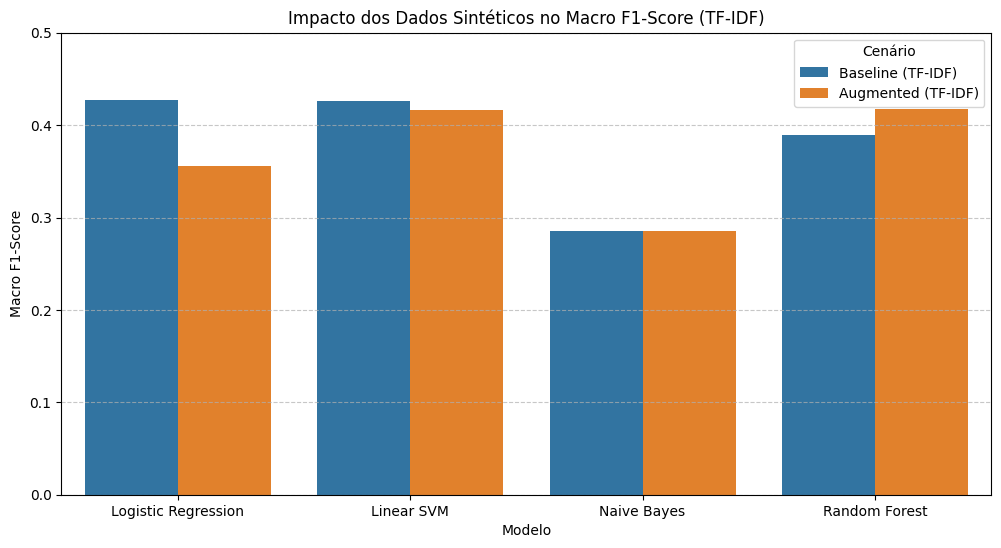

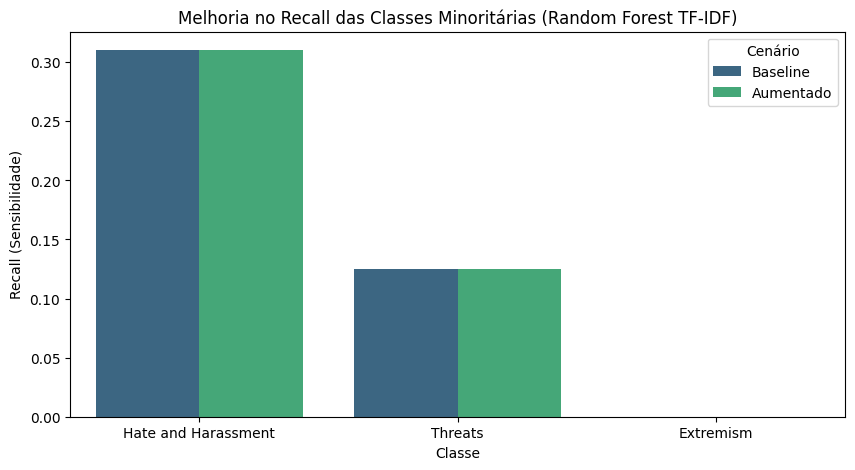

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import recall_score

# 1. Preparação dos dados para a tabela comparativa
data = {
    'Modelo': ['Logistic Regression', 'Linear SVM', 'Naive Bayes', 'Random Forest'],
    'Baseline (TF-IDF)': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_nb, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'Augmented (TF-IDF)': [
        results_aug['LR'],
        results_aug['SVM'],
        results_aug['NB'],
        results_aug['RF']
    ],
    'Baseline (W2V)': [
        f1_score(y_test, y_pred_lr_w2v, average='macro'),
        f1_score(y_test, y_pred_svm_w2v, average='macro'),
        f1_score(y_test, y_pred_nb_w2v, average='macro'),
        f1_score(y_test, y_pred_rf_w2v, average='macro')
    ],
    'Augmented (W2V)': [
        results_aug_w2v['LR'],
        results_aug_w2v['SVM'],
        results_aug_w2v['NB'],
        results_aug_w2v['RF']
    ]
}

df_results = pd.DataFrame(data)

print("=== TABELA COMPARATIVA DE DESEMPENHO (MACRO F1-SCORE) ===")
# Correção: Aplicar destaque apenas nas colunas numéricas
display(df_results.style.highlight_max(axis=1, color='darkgreen', subset=df_results.columns[1:]))

# 2. Gráfico de Comparação Geral
plt.figure(figsize=(12, 6))
df_plot = pd.melt(df_results, id_vars=['Modelo'], value_vars=['Baseline (TF-IDF)', 'Augmented (TF-IDF)'],
                  var_name='Cenário', value_name='Macro F1-Score')

sns.barplot(data=df_plot, x='Modelo', y='Macro F1-Score', hue='Cenário')
plt.title('Impacto dos Dados Sintéticos no Macro F1-Score (TF-IDF)')
plt.ylim(0, 0.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Comparação de Recall por Classe (Melhor Modelo TF-IDF: Random Forest)
classes_min = [3.0, 4.0, 5.0]
labels_min = [class_mapping[c] for c in classes_min]

recalls_base = [recall_score(y_test, y_pred_rf, labels=[c], average='macro') for c in classes_min]
recalls_aug = [recall_score(y_test, y_pred_rf_aug, labels=[c], average='macro') for c in classes_min]

df_recall = pd.DataFrame({
    'Classe': labels_min,
    'Baseline': recalls_base,
    'Aumentado': recalls_aug
}).melt(id_vars='Classe', var_name='Cenário', value_name='Recall')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_recall, x='Classe', y='Recall', hue='Cenário', palette='viridis')
plt.title('Melhoria no Recall das Classes Minoritárias (Random Forest TF-IDF)')
plt.ylabel('Recall (Sensibilidade)')
plt.show()